# 🔧 Preprocessing — Exploration & Validation
## Projet : Optimisation du ROI Marketing

**Objectif :** Valider visuellement chaque étape du pipeline défini dans `src/preprocessing/pipeline.py`

---


## 0. Imports

In [10]:
import sys
import os
sys.path.append('..')  # pour importer src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Import du pipeline maison
from src.preprocessing.pipeline import (
    load_data, build_preprocessor,
    load_and_prepare_data, save_preprocessor,
    NUM_FEATURES, CAT_FEATURES, TARGET_COL
)

sns.set_theme(style='whitegrid')
os.makedirs('../reports', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Chargement et nettoyage

In [11]:
df = load_data('../data/marketing_and_sales.csv')

print(f'Shape après nettoyage : {df.shape}')
print(f'Valeurs manquantes restantes : {df.isnull().sum().sum()}')
df.head()

  [nettoyage] 6 ligne(s) supprimée(s) (Sales manquant)
  [nettoyage] Dataset final : 4566 lignes × 5 colonnes
Shape après nettoyage : (4566, 5)
Valeurs manquantes restantes : 20


,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


## 2. Vérification du split Train / Test

Train : 3652 exemples (80%)
Test  : 914 exemples (20%)


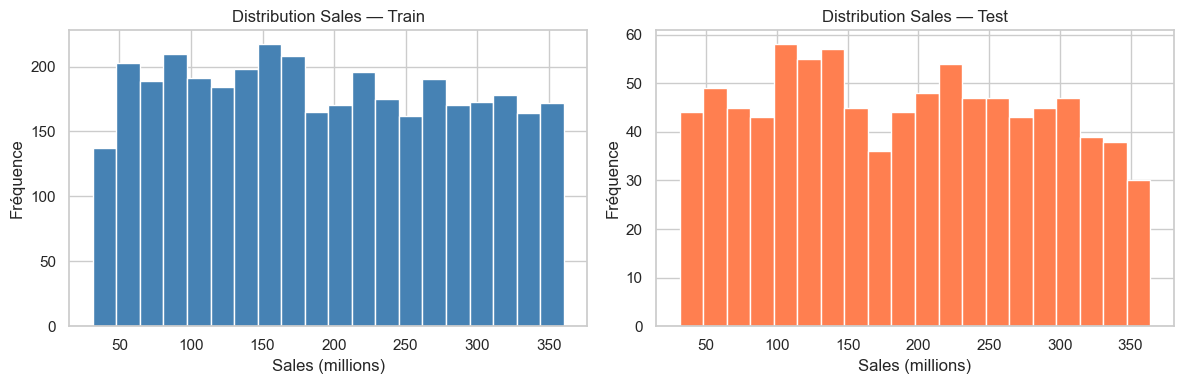


Moyenne Sales — Train : 192.87 | Test : 190.87
✅ Distributions similaires → split équilibré


In [ ]:
X = df[NUM_FEATURES + CAT_FEATURES]
y = df[TARGET_COL]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train : {X_train_raw.shape[0]} exemples ({X_train_raw.shape[0]/len(df)*100:.0f}%)')
print(f'Test  : {X_test_raw.shape[0]} exemples ({X_test_raw.shape[0]/len(df)*100:.0f}%)')

# Vérification : la distribution de Sales est-elle préservée ?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=20, color='steelblue', edgecolor='white', label='Train')
axes[0].set_title('Distribution Sales — Train')
axes[1].hist(y_test, bins=20, color='coral', edgecolor='white', label='Test')
axes[1].set_title('Distribution Sales — Test')
for ax in axes:
    ax.set_xlabel('Sales (millions)')
    ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig('../reports/train_test_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nMoyenne Sales — Train : {y_train.mean():.2f} | Test : {y_test.mean():.2f}')
print('Distributions similaires → split équilibré')

## 3. Validation de l'encodage One-Hot (Influencer)

In [13]:
preprocessor = build_preprocessor()
preprocessor.fit(X_train_raw)  # FIT uniquement sur le train !

# Noms des features après OHE
ohe_cats = preprocessor.named_transformers_['cat']['encoder'].categories_[0]
feature_names = NUM_FEATURES + list(ohe_cats)

print('Features après transformation :')
for i, name in enumerate(feature_names):
    print(f'  [{i}] {name}')

Features après transformation :
  [0] TV
  [1] Radio
  [2] Social Media
  [3] Macro
  [4] Mega
  [5] Micro
  [6] Nano


## 4. Validation de la standardisation

In [ ]:
X_train_proc = preprocessor.transform(X_train_raw)
X_test_proc  = preprocessor.transform(X_test_raw)

# Convertir en DataFrame pour lisibilité
df_train_proc = pd.DataFrame(X_train_proc, columns=feature_names)

print('=== STATISTIQUES APRÈS STANDARDISATION (variables numériques) ===')
print(df_train_proc[NUM_FEATURES].describe().round(3))

# Vérification : moyenne ≈ 0, std ≈ 1
print('\n Vérification : moyenne ≈ 0 et std ≈ 1 pour chaque variable numérique')

=== STATISTIQUES APRÈS STANDARDISATION (variables numériques) ===
             TV     Radio  Social Media
count  3652.000  3652.000      3652.000
mean     -0.000    -0.000         0.000
std       1.000     1.000         1.000
min      -1.693    -1.882        -1.490
25%      -0.850    -0.787        -0.817
50%      -0.046    -0.036        -0.124
75%       0.874     0.782         0.671
max       1.755     3.188         4.791

✅ Vérification : moyenne ≈ 0 et std ≈ 1 pour chaque variable numérique


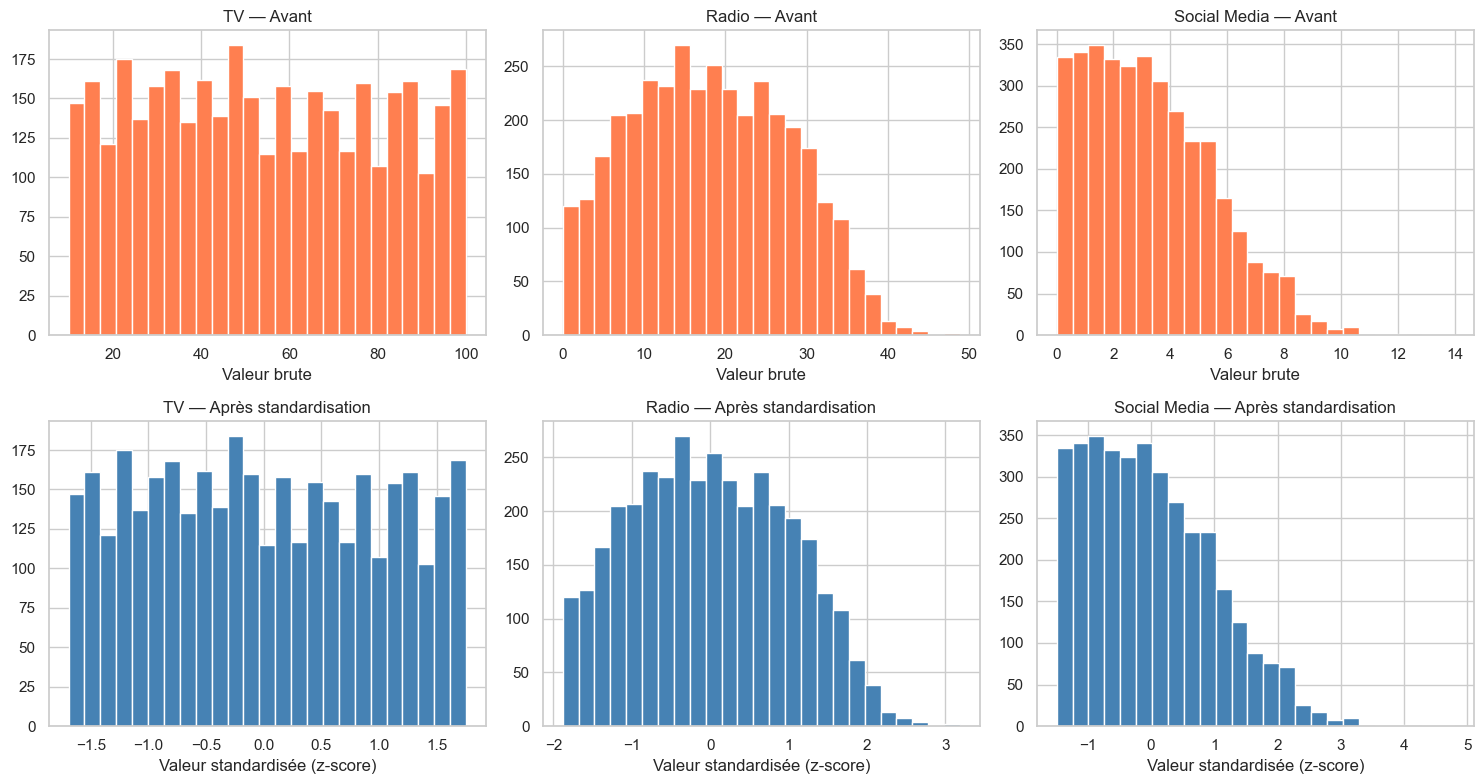

In [15]:
# Visualisation avant / après standardisation
fig, axes = plt.subplots(2, len(NUM_FEATURES), figsize=(5 * len(NUM_FEATURES), 8))

for i, col in enumerate(NUM_FEATURES):
    # Avant
    axes[0, i].hist(X_train_raw[col].dropna(), bins=25, color='coral', edgecolor='white')
    axes[0, i].set_title(f'{col} — Avant')
    axes[0, i].set_xlabel('Valeur brute')

    # Après
    axes[1, i].hist(df_train_proc[col], bins=25, color='steelblue', edgecolor='white')
    axes[1, i].set_title(f'{col} — Après standardisation')
    axes[1, i].set_xlabel('Valeur standardisée (z-score)')

plt.tight_layout()
plt.savefig('../reports/standardisation_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Exécution du pipeline complet + sauvegarde

In [17]:
X_train, X_test, y_train, y_test, preprocessor, feature_names = load_and_prepare_data(
    path='../data/marketing_and_sales.csv'
)

# Sauvegarde du preprocessor
save_preprocessor(preprocessor, path='../models/preprocessor.pkl')

print(f'\n Résumé final :')
print(f'  X_train : {X_train.shape}')
print(f'  X_test  : {X_test.shape}')
print(f'  Features : {feature_names}')
print('\n Preprocessing validé — prêt pour la modélisation (étape 5)')

🔄 Chargement et nettoyage...
  [nettoyage] 6 ligne(s) supprimée(s) (Sales manquant)
  [nettoyage] Dataset final : 4566 lignes × 5 colonnes
  [split] Train : 3652 | Test : 914
🔄 Fitting du preprocessor sur le train set...
  [features] 7 features finales : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']
Preprocessing terminé.
💾 Preprocessor sauvegardé → ../models/preprocessor.pkl

 Résumé final :
  X_train : (3652, 7)
  X_test  : (914, 7)
  Features : ['TV', 'Radio', 'Social Media', 'Macro', 'Mega', 'Micro', 'Nano']

 Preprocessing validé — prêt pour la modélisation (étape 5)
